In [1]:
# %%file SolveLoads.py
import sys
sys.path.append('../')

import numpy as np
from Equilibrium import *
from constants import *

def SolveACLoads(cg, acf, acb):
    Weight = PointLoad([0, - mTO * 9.81, 0], [cg, 0, 0])
    LFront = PointLoad([0, 1, 0], [acf, 0, 0])
    LBack = PointLoad([0, 1, 0], [acb, 0, 0])
    motion = EquilibriumEquation(kloads = [Weight], ukloads=[LFront, LBack])
    motion.SetupEquation()
    return list(motion.SolveEquation())

def SolveWingLoads(MAC, b, Lwing, Dwing, mWing, TpE, nE):
    pos = np.linspace(0, b / 2)
    WingWeight = RunningLoad([[0]*len(pos), [- mWing * 9.81 / b]*len(pos)], pos, axis=2)
    Lift = RunningLoad([[0]*len(pos), [Lwing * 2 / b] * len(pos)], pos, axis=2)
    Drag = RunningLoad([[Dwing * 2 / b] * len(pos), [0]*len(pos)], pos, axis=2)
    Thrust = [PointLoad([-TpE, 0, 0], [0, 0, i]) for i in np.linspace(0, b, nE)]
    MomentAC = Moment(value=[0, 0, 30])

    Fixedx = PointLoad([1, 0, 0], [0.5 * MAC, 0, 0])
    Fixedy = PointLoad([0, 1, 0], [0.5 * MAC, 0, 0])
    Fixedz = PointLoad([0, 0, 1], [0.5 * MAC, 0, 0])

    FixedMomentx, FixedMomenty, FixedMomentz = Moment([1, 0, 0]), Moment([0, 1, 0]), Moment([0, 0, 1])
    wingequation = EquilibriumEquation(kloads=[WingWeight, Lift, Drag, MomentAC] + Thrust,
                                       ukloads=[Fixedx, Fixedy, Fixedz, FixedMomentx, FixedMomenty, FixedMomentz])
    wingequation.SetupEquation()
    return wingequation

In [2]:
print(ACLoads := SolveACLoads(1.95, 0.5, 3.5))
wingequation = SolveWingLoads(0.2, 11.2, ACLoads[0], 800, mTO / 8, 100, 3)
print(WingLoads := list(wingequation.SolveEquation()))

[9787.273500000003, 9155.8365]
[-500.0, -8603.329125000004, 0.0, 24089.321550000008, -560.0, 830.3329125000005]


In [3]:
# uk: [ Fixedx, Fixedy, Fixedz, FixedMomentx, FixedMomenty, FixedMomentz ]
# C1: [ -700.      -7419.38475     0.      20774.2773    -1960.       0. ]
# C2: [ -600.      -7103.66625     0.      19890.2655    -1680.       0. ]
# C3: [ -800.    -14883.87214286   0.     41674.842      -2240.       0. ]

In [4]:

class WingBox:
    def __init__(self, thickness, base, height):
        self.b, self.h, self.t = base, height, thickness
    
    Area = lambda self: self.b * self.h - (self.b - 2 * self.t) * (self.h - 2 * self.t)

    Ixx = lambda self: (self.t * self.h ** 3 + self.b * self.t ** 3) / 6 + (self.t * self.b * self.h ** 2) / 2
    
    Iyy = lambda self: (self.t ** 3 * self.h + self.b ** 3 * self.t) / 6 + (self.t * self.h * self.b ** 2) / 2
    
    Vc = Ixy = lambda self: 0
    
    def Vshear(self, Vy):
        pass
    

In [59]:
from MathFunctions.Mechanics import StepFunction
from MathFunctions.Polynomial import Polynomial
import seaborn as sns
import pandas as pd

class WingStructure:
    def __init__(self, wingequation, ):
        WingLoads = wingequation.SolveEquation()
        self.RFx, self.RFy, self.RFz = WingLoads[:3]
        self.RMx, self.RMy, self.RMz = WingLoads[3:] # WingWeight, Lift, Drag, MomentAC, Thrust
        self.W, self.L, self.D, self.Mac, *self.T = wingequation.k

        self.N = self.Vx = self.Vy = self.Mz = self.Mx = self.My = None
        self.v = self.w = self.phi = None

    def compute_loading(self):
        self.N = StepFunction([[self.RFz, 0, 0]])
        qxzcoef = list(np.polyfit(self.W.p, self.W.v[0] + self.D.v[0] + self.L.v[0], 4))
        qyzcoef = list(np.polyfit(self.W.p, self.W.v[1] + self.D.v[1] + self.L.v[1], 4))
        qxz = StepFunction([[xi, 0, i] for i, xi in enumerate(qxzcoef)])
        qyz = StepFunction([[yi, 0, i] for i, yi in enumerate(qyzcoef)])
        self.Vx = StepFunction([[self.RFx, 0, 0]] + [[T.f[0], T.p[2], 0] for T in self.T]) + qxz.integral()
        self.Vy = StepFunction([[self.RFy, 0, 0]] + [[T.f[1], T.p[2], 0] for T in self.T]) + qyz.integral()
        self.Mz = self.L.pa[0] * qyz.integral() - self.L.pa[1] * qxz.integral()
        self.My, self.Mx = self.Vx.integral(), self.Vy.integral()
        return [self.N, self.Vx, self.Vy, self.Mx, self.My, self.Mz]

    def compute_deflections(self, E, Ixx, Iyy=None):
        Iyy = Ixx if Iyy is None else Iyy
        self.v = self.My.integral().integral() / (E * Ixx)
        self.w = self.Mx.integral().integral() / (E * Iyy)
        return self.v, self.w
    
    def create_nvm(self, b):
        x = np.linspace(0, b/2, 100)
        df = pd.DataFrame({'v': [self.v(xi) for xi in x], 'w': [self.w(xi) for xi in x], 'z': x}).set_index('z')
        df.plot()
        

In [60]:
wing = WingStructure(wingequation)
wing.compute_loading()
wing.compute_deflections(60e9, 1.005e-5, 1.005e-2)[0]

-0.00017[z]^3 -3e-05[z-5.6]^3 -3e-05[z-11.2]^3 -0.0[z]^4 +0.0[z]^5 -0.0[z]^6 +0.0[z]^7 +0.0[z]^8

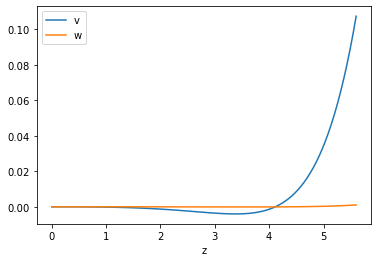

In [65]:
import matplotlib.pyplot as plt
wing.create_nvm(11.2)